# Chapter 17. 한국어 BERT Multi-label — KLUE-YNAT 합성 multi-label

**목표**: Ch 16 의 한국어 multi-class 셋업을 그대로 두고 **task 만 single-label → multi-label** 로 바꿉니다. 모델·토크나이저·hyperparams 가 *완전히 동일* 하고, 변하는 건 라벨이 *하나* 가 아니라 *여러 개 동시 활성* 될 수 있다는 점과 그에 따른 loss/activation.

KLUE-YNAT 에는 multi-label 정답이 없습니다. 그래서 *서로 다른 두 뉴스 헤드라인을 이어붙여* 두 카테고리가 동시에 활성된 합성 multi-label 샘플을 직접 만듭니다 — 한 헤드라인이 *여러 주제에 걸치는* 상황을 시뮬레이션.

이 챕터는 Ch 13 (영어 multi-label, Yelp 항목 합성) 의 한국어 버전입니다. *합성 방식* 만 다릅니다 — Ch 13 은 키워드 매칭으로 라벨을 붙였고, Ch 17 은 두 single-label 샘플을 *결합* 해 라벨을 union 합니다.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 3분 (모델 다운로드 ~30s + 2 에폭 학습 약 40초 + 평가/시각화)

---

## 학습 흐름

1. 🚀 **실습**: KLUE-YNAT 헤드라인 두 개를 결합해 multi-label 5,000건 합성 → klue/bert-base 를 `multi_label_classification` 으로 파인튜닝
2. 🔬 **해부**: 카테고리별 sigmoid 확률 분포 (7 패널 KDE) + 카테고리 간 공동 활성 패턴 (co-occurrence heatmap)
3. 🛠️ **변형**: 합성 샘플을 직접 읽어보며 모델이 *두 주제를 모두 잡는지* 확인 + threshold 를 옮기면 결과가 어떻게 바뀌는지

---

> 📒 **사전 학습 자료**: Ch 13 (영어 multi-label, per-label BCE), Ch 16 (한국어 multi-class, KLUE-YNAT). 이번 챕터는 두 챕터의 *결합* — Ch 16 의 한국어 셋업 + Ch 13 의 multi-label 처리.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 13 | DistilBERT | WordPiece (영어) | Yelp + 항목 키워드 합성 | `Linear(H, 5)` | sigmoid (per-label) | `BCEWithLogitsLoss` (per-label) |
| 15 | klue/bert-base | WordPiece (한국어) | NSMC binary | `Linear(H, 2)` | softmax | `CrossEntropyLoss` |
| 16 | klue/bert-base | 같음 | KLUE-YNAT (뉴스 7분류) | `Linear(H, 7)` | softmax | `CrossEntropyLoss` |
| **17 ← 여기** | klue/bert-base | 같음 | **KLUE-YNAT 합성 multi-label (두 헤드라인 결합)** | `Linear(H, 7)` | **sigmoid (per-label)** | **`BCEWithLogitsLoss` (per-label)** |
| 18 (다음) | klue/bert-base | 같음 | KLUE-YNAT 합성 multi-label + 라벨 개수 보조 | `Linear(H, 7)` 메인 + `Linear(H, 1)` 보조 | sigmoid + 없음 | `BCE(per-label) + λ·MSE` |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

## 🔄 변경점 (Diff from Ch 16)

| 축 | Ch 16 (한국어 multi-class) | Ch 17 (한국어 multi-label) |
|---|---|---|
| **Task** | 7-클래스 *single-label* (서로 배타적) | **7-라벨 *multi-label*** (동시 활성 가능) ← *유일한 변화* |
| `num_labels` | 7 | **7** (그대로!) |
| `problem_type` | `"single_label_classification"` | **`"multi_label_classification"`** ← BCE 자동 매핑 |
| Activation | softmax (합=1 강제) | **per-label sigmoid** (각각 독립 0-1) |
| Loss | `CrossEntropyLoss` | **`BCEWithLogitsLoss`** per-label |
| 라벨 형식 | int 스칼라 (0-6) | **multi-hot float 7차원 `[0, 1, 0, 0, 0, 1, 0]`** |
| 데이터 | KLUE-YNAT 원본 헤드라인 | **두 헤드라인 결합 → 두 카테고리 union** |
| 평가 metric | accuracy + macro F1 + AUC OvR | **hamming loss + micro/macro F1 + per-label F1 + macro AUC** |
| 모델 본체 / 토크나이저 / hyperparams | (모두 동일) | (모두 동일) |

> **변경점 한 가지 원칙** — Phase 2 안에선 *task 차원* (single-label → multi-label) 만 바뀝니다. 한국어 셋업·hyperparams 는 Ch 16 과 *완전히 같음*. 모델 아키텍처조차 `Linear(H, 7)` 그대로 — `problem_type` 한 줄과 라벨 *형식* 만 바뀝니다.

### 같은 7차원 출력을 두 가지로 해석

Ch 16 과 Ch 17 의 모델은 둘 다 `Linear(768, 7)` 헤드를 가집니다. 차이는 *그 7개 숫자를 어떻게 읽는가*:

- **Ch 16 (softmax)**: 7개를 *한꺼번에* 정규화해 합=1 로 만든 뒤 *가장 큰 하나* 를 고름. "이 헤드라인은 7개 카테고리 중 *정확히 하나*".
- **Ch 17 (per-label sigmoid)**: 7개 각각을 *독립적으로* 0-1 확률로 변환. "이 헤드라인에 각 카테고리가 *각자* 활성됐는가?" — 여러 개가 동시에 1 일 수 있음.

## 📐 Loss 함수의 변화 — `CrossEntropyLoss` → `BCEWithLogitsLoss` per-label

Ch 16 의 multi-class CE 는 *정답 클래스 하나* 의 로그확률만 봤습니다:

$$L_{\text{CE}} = -\frac{1}{N}\sum_{i=1}^{N}\log \hat p_{i, y_i}$$

Ch 17 은 K=7 개 라벨 각각에 *독립적* BCE 를 적용한 뒤 평균합니다 (Ch 13 의 식 그대로, 한국어 맥락):

$$L_{\text{BCE}} = -\frac{1}{N \cdot K}\sum_{i=1}^{N}\sum_{k=1}^{K}\left[ y_{i,k} \log \sigma(z_{i,k}) + (1-y_{i,k}) \log(1-\sigma(z_{i,k})) \right]$$

각 $z_{i,k}$ 는 *독립 logit* — 카테고리 k 가 *얼마나 활성될지* 의 점수, 다른 카테고리와 무관. PyTorch `BCEWithLogitsLoss` 가 7개 위치를 한 번에 처리하지만 수식적으론 7개의 binary BCE 평균입니다.

**숫자로 감 잡기 (K=7, 정답 multi-hot $\mathbf{y} = [0, 1, 0, 0, 0, 1, 0]$ — 경제+스포츠 동시 활성)** — logit 별 손실 분해:

| 라벨 | 카테고리 | $y_k$ | logit $z_k$ | $\sigma(z_k)$ | 손실 $-\log(\cdot)$ |
|---|---|---|---|---|---|
| 1 | 경제 | 1 | 3.0 | 0.953 | 0.048 |
| 5 | 스포츠 | 1 | 0.5 | 0.622 | 0.474 |
| 0 | IT과학 | 0 | -2.0 | 0.119 | 0.127 |
| 2 | 사회 | 0 | 1.5 | 0.818 | 1.704 ← 자신 있게 틀림 |
| 나머지 3개 | (음성) | 0 | -3.0 | 0.047 | 각 0.048 |

평균 loss = $(0.048 + 0.474 + 0.127 + 1.704 + 0.048 \times 3) / 7 \approx 0.387$.

**핵심 직관 — 라벨 사이엔 직접 신호가 없음**: BCE per-label 은 카테고리 k 의 logit 이 카테고리 j 의 정답에서 *직접* 학습 신호를 받지 않습니다. 모델이 카테고리 간 상관을 학습하는 건 *공유 BERT 본체* (모든 라벨이 같은 768-dim CLS 표현에서 옴) 덕분이지 loss 자체엔 라벨 간 결합 항이 없습니다.

**코드 한 줄 변화** — Ch 16 → Ch 17:

```python
# Ch 16: int 스칼라 라벨 + single_label_classification
out["labels"] = [int(l) for l in batch["label"]]
problem_type = "single_label_classification"   # → CrossEntropyLoss

# Ch 17: multi-hot 7차원 float 라벨 + multi_label_classification
out["labels"] = [list(map(float, mh)) for mh in batch["multi_hot"]]
problem_type = "multi_label_classification"     # → BCEWithLogitsLoss per-label
```

### 왜 multi-label 은 softmax 로 풀 수 없는가

softmax 는 출력의 *합 = 1* 을 강제합니다 ($\sum_k \mathrm{softmax}(z)_k = 1$). 이는 *서로 배타적* 클래스 (Ch 16) 에 자연스럽지만 multi-label 과 충돌합니다.

합성 샘플이 "경제 헤드라인 + 스포츠 헤드라인" 이라 정답이 경제=1, 스포츠=1 일 때:
- **softmax 모델은 표현 불가**: P(경제)=0.6 이면 나머지 6 라벨 합이 0.4 로 강제 → '스포츠=0.55 동시 활성' 이 *수학적으로 불가능*.
- **per-label sigmoid 모델은 표현 가능**: 각 라벨이 독립이라 P(경제)=0.9 와 P(스포츠)=0.85 가 동시에 자연스러움.

즉 task 가 *진짜 multi-label* 이라면 loss/activation 선택이 강제됩니다 (Ch 4·13 에서 본 동일한 논리).

## 🔤 토크나이저 노트

Ch 16 과 *완전히 동일* — `klue/bert-base` 한국어 WordPiece. 토크나이저는 라벨 *형식* (int 스칼라든 multi-hot 벡터든) 에 무관하므로 변화 없음.

> **Phase 2 안에서는 토크나이저 고정** — Ch 15·16·17·18 모두 같은 한국어 WordPiece. Phase 3 의 첫 챕터(Ch 19)에서 비로소 *토크나이저를 직접 학습* 해 WordPiece 와 WordLevel 을 비교하고, Ch 20-23 의 사전학습은 다시 기성 WordPiece 토크나이저를 가져와 씁니다.

### 결합 헤드라인 토큰화 예시

Ch 16 은 헤드라인 *한 줄* (평균 약 16 토큰) 이었지만, Ch 17 은 두 헤드라인을 `[SEP]` 로 이어붙여 *길이가 약 2배* (평균 약 30 토큰, 최대 41) 가 됩니다. `max_length=128` 안에 충분히 들어갑니다.

두 문장을 잇는 `[SEP]` 토큰은 BERT 가 *문장 경계* 를 인식하는 특수 토큰입니다 — NSP (Next Sentence Prediction) 사전학습에서 쓰던 그 토큰. 결합 헤드라인에선 두 주제의 경계 역할을 합니다.

> **다음 챕터 (Ch 18)**: 토크나이저 그대로. 변하는 건 *모델에 보조 헤드* (활성 라벨 *개수* 회귀) 가 추가되고 *loss 에 보조 항* 이 가중합으로 더해지는 점.

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import (
    precision_recall_fscore_support, classification_report,
    roc_auc_score, hamming_loss,
)

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# device 자동감지 — Colab(T4) 은 CUDA, 로컬 Mac 은 MPS, 그 외 CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device:         {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
elif DEVICE == "cpu":
    print("Warning: CPU runtime — training will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
Device:         cuda
GPU:             Tesla T4


**baseline VRAM** (CUDA 환경에서만 의미 있는 출력 — Colab T4 기준):

In [3]:
!nvidia-smi

Sun Sep  6 06:04:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 🚀 데이터 — KLUE-YNAT 결합으로 multi-label 합성

**KLUE-YNAT** 은 single-label 데이터 (헤드라인 한 줄 → 카테고리 하나) 라 multi-label 정답이 없습니다. Ch 13 에서 Yelp 에 항목 키워드를 합성했듯, 여기선 *서로 다른 두 헤드라인을 결합* 해 두 카테고리가 동시에 활성된 샘플을 만듭니다.

| 라벨 | 카테고리 |
|---|---|
| 0 | IT과학 |
| 1 | 경제 |
| 2 | 사회 |
| 3 | 생활문화 |
| 4 | 세계 |
| 5 | 스포츠 |
| 6 | 정치 |

> **합성 방식**: 샘플 A (카테고리 $c_A$) 와 샘플 B (카테고리 $c_B$) 를 뽑아 (1) 텍스트를 `" [SEP] "` 로 이어붙이고 (2) multi-hot 라벨에서 $c_A, c_B$ 두 위치를 1 로. 우연히 $c_A = c_B$ 면 활성 라벨은 1개뿐 (자연스러운 single-label 케이스도 일부 섞임).

In [4]:
ds = load_dataset("klue/klue", "ynat")
print(f"splits: {list(ds.keys())}")
print(f"sizes: {[(k, len(v)) for k, v in ds.items()]}")

LABEL_NAMES = ds["train"].features["label"].names   # KLUE-YNAT 원본 (한국어)
# 출력·플롯은 영문으로 (matplotlib 한글 폰트 깨짐·조판 문제 방지)
_KO2EN = {"IT과학": "IT/Science", "경제": "Economy", "사회": "Society", "생활문화": "Life&Culture", "세계": "World", "스포츠": "Sports", "정치": "Politics"}
LABEL_NAMES_EN = [_KO2EN.get(n, n) for n in LABEL_NAMES]
K = len(LABEL_NAMES)
print(f"label names ({K}): {LABEL_NAMES}")

# title 컬럼명을 'text' 로 통일 (transformers 표준)
ds = ds.rename_column("title", "text")
print(f"\nfirst 2 raw samples:")
for ex in ds["train"].select(range(2)):
    print(f"  label={ex['label']} ({LABEL_NAMES_EN[ex['label']]:>8})  text={ex['text']!r}")

README.md:   0%|          | 0.00/22.5k [00:00<?, ?B/s]

ynat/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.17MB            

ynat/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

ynat/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  847kB            

ynat/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45678 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9107 [00:00<?, ? examples/s]

splits: ['train', 'validation']
sizes: [('train', 45678), ('validation', 9107)]
label names (7): ['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

first 2 raw samples:
  label=3 (Life&Culture)  text='유튜브 내달 2일까지 크리에이터 지원 공간 운영'
  label=3 (Life&Culture)  text='어버이날 맑다가 흐려져…남부지방 옅은 황사'


### 1-1. 두 헤드라인을 결합해 multi-label 샘플 합성

`make_multilabel` 이 single-label split 을 받아 *짝* 을 지어 합성 데이터셋을 만듭니다. seed 를 고정해 train/eval 이 재현 가능하게.

In [5]:
SEED = 42
N_TRAIN = 5000
N_EVAL  = 1000


def make_multilabel(source_split, n_samples, seed):
    '''single-label split 에서 두 샘플씩 결합해 multi-label 데이터셋 합성.

    - 2*n_samples 개 인덱스를 섞어 앞/뒤 절반을 짝으로 묶음
    - 텍스트는 " [SEP] " 로 이어붙임
    - multi-hot 라벨은 두 카테고리 위치를 1 로 (같은 카테고리면 1개만)
    '''
    rng = np.random.default_rng(seed)
    n_src = len(source_split)
    # 짝지을 인덱스 2*n_samples 개 (중복 허용 — 소스가 부족할 때 대비)
    # numpy.int64 로 datasets 컬럼을 인덱싱하면 TypeError → python int 로 캐스팅
    idx = rng.integers(0, n_src, size=2 * n_samples).tolist()
    idx_a, idx_b = idx[:n_samples], idx[n_samples:]

    # 컬럼을 미리 파이썬 list 로 (반복 인덱싱이 빠르고 타입 안전)
    src_text = list(source_split["text"])
    src_label = list(source_split["label"])

    texts, multi_hots, active_counts = [], [], []
    for a, b in zip(idx_a, idx_b):
        ca, cb = int(src_label[a]), int(src_label[b])
        combined = f"{src_text[a]} [SEP] {src_text[b]}"
        mh = [0.0] * K
        mh[ca] = 1.0
        mh[cb] = 1.0   # ca == cb 면 같은 위치 → 활성 1개
        texts.append(combined)
        multi_hots.append(mh)
        active_counts.append(int(sum(mh)))
    return Dataset.from_dict({
        "text": texts,
        "multi_hot": multi_hots,
        "n_active": active_counts,
    })


train_full = make_multilabel(ds["train"], N_TRAIN, seed=SEED)
eval_full  = make_multilabel(ds["validation"], N_EVAL, seed=SEED + 1)

print(f"synthetic train: {len(train_full)}")
print(f"synthetic eval:  {len(eval_full)}")
print(f"\nFirst synthetic sample:")
print(f"  text:      {train_full[0]['text']}")
print(f"  multi_hot: {train_full[0]['multi_hot']}")
active0 = [LABEL_NAMES_EN[k] for k in range(K) if train_full[0]['multi_hot'][k] > 0]
print(f"  active categories: {active0}")

synthetic train: 5000
synthetic eval:  1000

First synthetic sample:
  text:      신간 언어와 탱크를 응시하며·자본주의 리얼리즘 [SEP] 우리은행 주택금융공사와 도시재생 발굴·지원 업무협약
  multi_hot: [0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0]
  active categories: ['Economy', 'Life&Culture']


In [6]:
# 카테고리별 활성률 + 활성 라벨 개수 분포
Y_train = np.array(train_full["multi_hot"])

print("Per-category activation rate (train):")
for k in range(K):
    rate = Y_train[:, k].mean()
    print(f"  {LABEL_NAMES_EN[k]:>9} (label {k}): {rate:.1%}  ({int(Y_train[:, k].sum())} / {len(Y_train)})")

n_active = Y_train.sum(axis=1)
print(f"\nMean active labels per sample: {n_active.mean():.2f}  (expected ~1.86: two draws, occasional collision)")
print(f"Active label distribution (train):")
for n in range(K + 1):
    cnt = int((n_active == n).sum())
    if cnt:
        print(f"  {n} labels active: {cnt} samples ({cnt/len(Y_train):.1%})")

Per-category activation rate (train):
  IT/Science (label 0): 22.0%  (1100 / 5000)
    Economy (label 1): 25.2%  (1260 / 5000)
    Society (label 2): 21.8%  (1089 / 5000)
  Life&Culture (label 3): 23.3%  (1165 / 5000)
      World (label 4): 32.8%  (1638 / 5000)
     Sports (label 5): 31.0%  (1549 / 5000)
   Politics (label 6): 29.3%  (1467 / 5000)

Mean active labels per sample: 1.85  (expected ~1.86: two draws, occasional collision)
Active label distribution (train):
  1 labels active: 732 samples (14.6%)
  2 labels active: 4268 samples (85.4%)


## 2. 토큰화 — Ch 16 패턴, 라벨 형식만 multi-hot

**Ch 16 과의 한 줄 차이**: `out["labels"] = [int(l) for l in batch["label"]]` → `out["labels"] = [list(map(float, mh)) for mh in batch["multi_hot"]]`. 라벨이 *int 스칼라* 가 아니라 *길이 7 multi-hot float 벡터*. 이 형식 + `problem_type="multi_label_classification"` 두 가지가 BCE per-label 자동 매핑의 트리거입니다.

In [7]:
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# 결합 헤드라인 토큰 길이 미리 보기
sample_lens = [len(tokenizer.encode(t)) for t in train_full["text"][:200]]
print(f"Token length (combined, sample 200): "
      f"mean={np.mean(sample_lens):.1f}, median={np.median(sample_lens):.0f}, max={max(sample_lens)}")


def tokenize_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    # multi-hot 7차원 float 벡터 (BCEWithLogitsLoss 가 받는 형식)
    out["labels"] = [list(map(float, mh)) for mh in batch["multi_hot"]]
    return out

keep = ("input_ids", "attention_mask", "token_type_ids", "labels")
train_tok = train_full.map(tokenize_fn, batched=True).remove_columns(
    [c for c in train_full.column_names if c not in keep]
)
eval_tok = eval_full.map(tokenize_fn, batched=True).remove_columns(
    [c for c in eval_full.column_names if c not in keep]
)

print(train_tok)
print(f"\nFirst sample label: {train_tok[0]['labels']}  (length-7 multi-hot float vector)")

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Token length (combined, sample 200): mean=30.0, median=30, max=41


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})

First sample label: [0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0]  (length-7 multi-hot float vector)


## 3. 모델 로드 — `num_labels=7` 그대로, `problem_type` 만 전환

Ch 16 과 *모델 아키텍처는 완전히 동일* (`Linear(H, 7)` 분류 헤드). 변하는 한 가지 — `problem_type="multi_label_classification"` — 가 자동 매핑되는 loss 를 BCE per-label 로 바꿉니다.

In [8]:
torch.manual_seed(SEED); np.random.seed(SEED)   # 분류 헤드 초기화까지 고정 — 재현성 확보
model = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=K,
    problem_type="multi_label_classification",   # ← BCEWithLogitsLoss per-label 자동 매핑
    id2label={i: name for i, name in enumerate(LABEL_NAMES_EN)},
    label2id={name: i for i, name in enumerate(LABEL_NAMES_EN)},
)

def param_summary(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total, trainable = param_summary(model)
print(f"Parameters:           {total:>13,}  ({total/1e6:.1f} M)")
print(f"Trainable parameters: {trainable:>13,}  ({trainable/total:.1%})")
print(f"Classifier:           {model.classifier}")
print(f"problem_type:         {model.config.problem_type}")
print(f"id2label:             {model.config.id2label}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters:             110,622,727  (110.6 M)
Trainable parameters:   110,622,727  (100.0%)
Classifier:           Linear(in_features=768, out_features=7, bias=True)
problem_type:         multi_label_classification
id2label:             {0: 'IT/Science', 1: 'Economy', 2: 'Society', 3: 'Life&Culture', 4: 'World', 5: 'Sports', 6: 'Politics'}


**Ch 16 과 파라미터 수가 *완전히 동일*** — 둘 다 `Linear(768, 7)` 헤드. 차이는 `problem_type` 한 줄뿐입니다. 같은 모델이 *어떻게 해석되고 어떤 loss 로 학습되는가* 만 바뀝니다. 이게 Ch 16 ↔ Ch 17 변경이 "한 가지 축" 인 이유 — *task 의 의미* 만 single-label → multi-label 로 옮기고 나머지는 전부 고정.

In [9]:
!nvidia-smi

Sun Sep  6 06:04:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4. 학습 — Ch 16 과 동일한 hyperparams

Ch 16 과 *완전히 같은* learning rate, batch size, epoch 수, seed. 평가 metric 만 multi-label 용으로 새로 짭니다 (Ch 13 의 패턴 그대로).

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred                      # logits: (N, K), labels: (N, K) float
    probs = 1.0 / (1.0 + np.exp(-logits))           # per-label sigmoid
    preds = (probs >= 0.5).astype(int)              # threshold 0.5

    out = {}
    # Hamming loss — 전체 라벨 위치 중 틀린 비율 (낮을수록 좋음)
    out["hamming_loss"] = float(hamming_loss(labels, preds))

    # Micro F1 — 전체 라벨을 한꺼번에 (TP/FP/FN 합산 후 F1)
    p_mi, r_mi, f1_mi, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0,
    )
    out["micro_f1"] = float(f1_mi)
    out["micro_precision"] = float(p_mi)
    out["micro_recall"]    = float(r_mi)

    # Macro F1 — 라벨별 F1 을 평균 (각 라벨에 동일 가중치)
    p_ma, r_ma, f1_ma, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0,
    )
    out["macro_f1"] = float(f1_ma)
    out["macro_precision"] = float(p_ma)
    out["macro_recall"]    = float(r_ma)

    # Per-label AUC 의 macro 평균
    try:
        out["macro_auc"] = float(roc_auc_score(labels, probs, average="macro"))
    except ValueError:
        out["macro_auc"] = float("nan")
    return out

In [11]:
training_args = TrainingArguments(
    output_dir="./ch17_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=True,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(f"\nTraining done — mean train loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Hamming Loss,Micro F1,Micro Precision,Micro Recall,Macro F1,Macro Precision,Macro Recall,Macro Auc,Runtime,Samples Per Second,Steps Per Second
1,0.231119,0.256440,0.099000,0.796834,0.822142,0.773038,0.808625,0.814437,0.820321,0.953456,0.944200,1059.123000,33.892000
2,0.176106,0.217527,0.077857,0.841616,0.860368,0.823663,0.847575,0.844402,0.854208,0.961867,0.693900,1441.224000,46.119000



Training done — mean train loss: 0.2604


In [12]:
!nvidia-smi

Sun Sep  6 06:05:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             36W /   70W |    2209MiB /  15360MiB |     72%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 5. 🔬 평가 — 카테고리별 sigmoid 확률 + 공동 활성 패턴

Ch 16 의 평가가 *7개 클래스 중 하나 고르기* 였다면, Ch 17 은 *7개 카테고리 각각을 독립적으로 0/1 판정* 합니다. Ch 13 의 multi-label 평가 패턴을 한국어 환경에서 재현.

In [13]:
eval_metrics = trainer.evaluate()
print("klue/bert-base KLUE-YNAT multi-label — evaluation:")
for k, v in eval_metrics.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>22}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Hamming Loss,Micro F1,Micro Precision,Micro Recall,Macro F1,Macro Precision,Macro Recall,Macro Auc,Runtime,Samples Per Second,Steps Per Second
0.176106,0.217527,2,0.077857,0.841616,0.860368,0.823663,0.847575,0.844402,0.854208,0.961867,0.682100,1466.153000,46.917000


klue/bert-base KLUE-YNAT multi-label — evaluation:
               eval_loss: 0.2175
       eval_hamming_loss: 0.0779
           eval_micro_f1: 0.8416
    eval_micro_precision: 0.8604
       eval_micro_recall: 0.8237
           eval_macro_f1: 0.8476
    eval_macro_precision: 0.8444
       eval_macro_recall: 0.8542
          eval_macro_auc: 0.9619
            eval_runtime: 0.6821
  eval_samples_per_second: 1466.1530
   eval_steps_per_second: 46.9170


In [14]:
# logits → per-label sigmoid → multi-hot 예측
preds_output = trainer.predict(eval_tok)
logits = preds_output.predictions                   # (N, 7)
labels = preds_output.label_ids.astype(int)         # (N, 7) multi-hot
probs  = 1.0 / (1.0 + np.exp(-logits))              # (N, 7) per-label prob
preds  = (probs >= 0.5).astype(int)                 # (N, 7) multi-hot prediction

print(f"logits shape: {logits.shape}")
print(f"prob ranges per category:")
for k in range(K):
    print(f"  {LABEL_NAMES_EN[k]:>9}: [{probs[:, k].min():.4f}, {probs[:, k].max():.4f}]  "
          f"true rate={labels[:, k].mean():.1%}, pred rate={preds[:, k].mean():.1%}")

logits shape: (1000, 7)
prob ranges per category:
  IT/Science: [0.0128, 0.9722]  true rate=12.6%, pred rate=13.4%
    Economy: [0.0093, 0.9901]  true rate=23.8%, pred rate=22.9%
    Society: [0.0349, 0.9603]  true rate=68.4%, pred rate=56.4%
  Life&Culture: [0.0111, 0.9924]  true rate=27.8%, pred rate=29.9%
      World: [0.0118, 0.9907]  true rate=15.9%, pred rate=17.0%
     Sports: [0.0078, 0.9926]  true rate=11.7%, pred rate=12.4%
   Politics: [0.0070, 0.9929]  true rate=15.6%, pred rate=16.3%


In [15]:
# Per-category classification report
print(classification_report(
    labels, preds,
    target_names=LABEL_NAMES_EN,
    digits=4, zero_division=0,
))

              precision    recall  f1-score   support

  IT/Science     0.7537    0.8016    0.7769       126
     Economy     0.8253    0.7941    0.8094       238
     Society     0.9184    0.7573    0.8301       684
Life&Culture     0.8294    0.8921    0.8596       278
       World     0.8647    0.9245    0.8936       159
      Sports     0.9032    0.9573    0.9295       117
    Politics     0.8160    0.8526    0.8339       156

   micro avg     0.8604    0.8237    0.8416      1758
   macro avg     0.8444    0.8542    0.8476      1758
weighted avg     0.8650    0.8237    0.8409      1758
 samples avg     0.8825    0.8425    0.8408      1758



### 5-1. 메인 그림 — 카테고리별 sigmoid 확률 KDE (7 패널)

Ch 16 에선 *top-1 확률 하나* 만 봤지만, multi-label 에선 *각 카테고리* 가 독립이라 7개 확률 분포를 *각각* 그립니다. 카테고리마다 학습 난이도가 *다를 수* 있다는 multi-label 의 본질이 시각적으로 드러납니다.

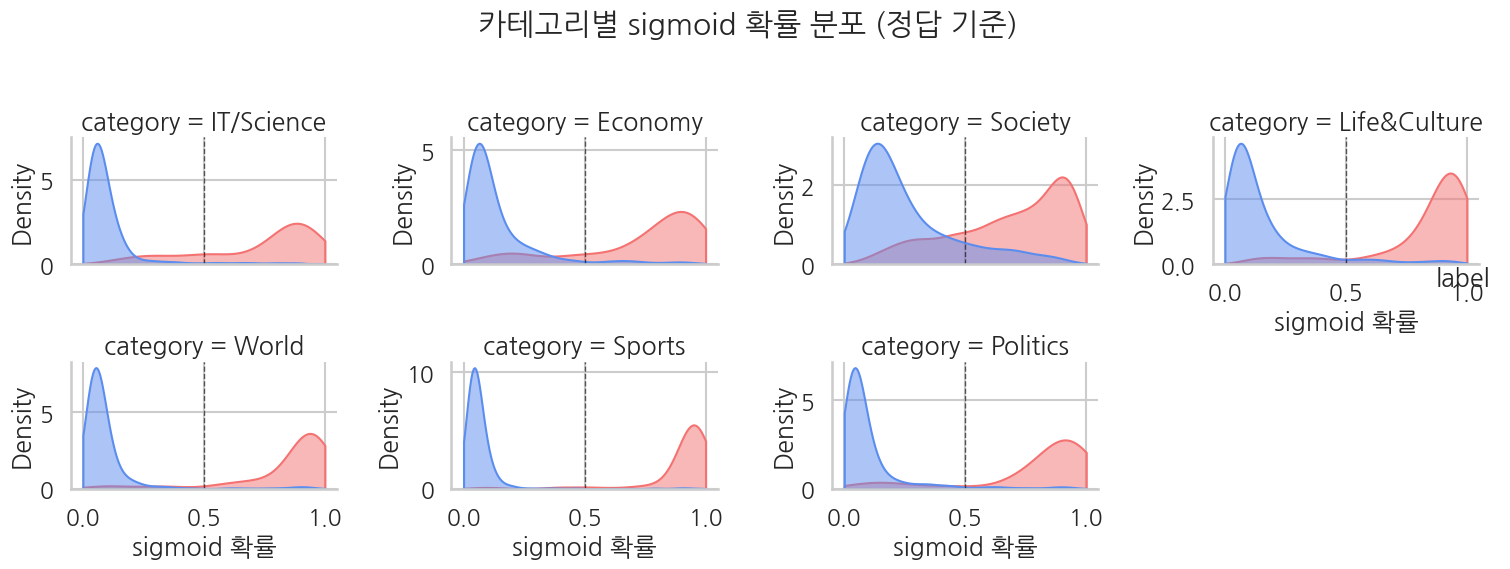

In [16]:
sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})

# Long-form DataFrame
records = []
for k in range(K):
    name = LABEL_NAMES_EN[k]
    for i in range(len(probs)):
        records.append({"category": name, "prob": probs[i, k], "label": int(labels[i, k])})
df_long = pd.DataFrame(records)

g = sns.FacetGrid(
    df_long, col="category", col_wrap=4, height=2.8, aspect=1.3,
    sharex=True, sharey=False,
)
g.map_dataframe(
    sns.kdeplot, x="prob", hue="label",
    fill=True, common_norm=False, alpha=0.5,
    palette={0: "#5B8DEF", 1: "#F47272"}, clip=(0, 1),
)
for ax in g.axes.flat:
    ax.axvline(0.5, color="black", lw=1.0, ls="--", alpha=0.6)
    ax.set_xlabel("sigmoid 확률")
g.add_legend(title="label")
g.fig.suptitle("카테고리별 sigmoid 확률 분포 (정답 기준)", y=1.03)
plt.tight_layout()
plt.show()

**해석**

- **잘 학습된 카테고리** (예: 스포츠): label=0 곡선은 0 근처, label=1 곡선은 1 근처에 있고 둘이 거의 만나지 않음. *분리가 깨끗*.
- **헷갈리는 카테고리** (예: 사회, IT과학): 두 곡선이 겹치거나 label=1 곡선이 넓게 퍼짐. 사회는 eval 활성률이 높아 온갖 결합에 섞이고, IT과학은 per-label F1 이 가장 낮은 카테고리 — 결합 헤드라인 안에서 두 주제 신호가 *섞일* 때 약해지는 지점.
- **결합의 부작용** — 한 샘플에 *두 헤드라인* 이 들어가니 모델이 "둘 중 어느 쪽 신호가 어느 라벨인지" 분리해야 합니다. 이게 단일 헤드라인 (Ch 16) 보다 어려운 점이고, multi-label task 의 자연스러운 난이도.

### 5-2. 보조 그림 — 카테고리 간 공동 활성 패턴

Multi-label 의 핵심 질문: *어떤 카테고리 쌍이 같이 등장하는가?* 합성이 *무작위 결합* 이라 특정 *의미 쌍* 의 상관은 없지만, P(j | i) 는 *상대 카테고리 j 의 활성률에 비례* 합니다 — eval 합성의 원천인 validation split 이 사회 쏠림이라 **사회 열이 뚜렷하게 높게** 나옵니다. 모델 예측이 이 패턴을 따라가는지 확인합니다.

`true co-occurrence` (실제 합성 라벨의 동시 등장) 와 `predicted co-occurrence` (모델 예측의 동시 등장) 를 나란히 그립니다.

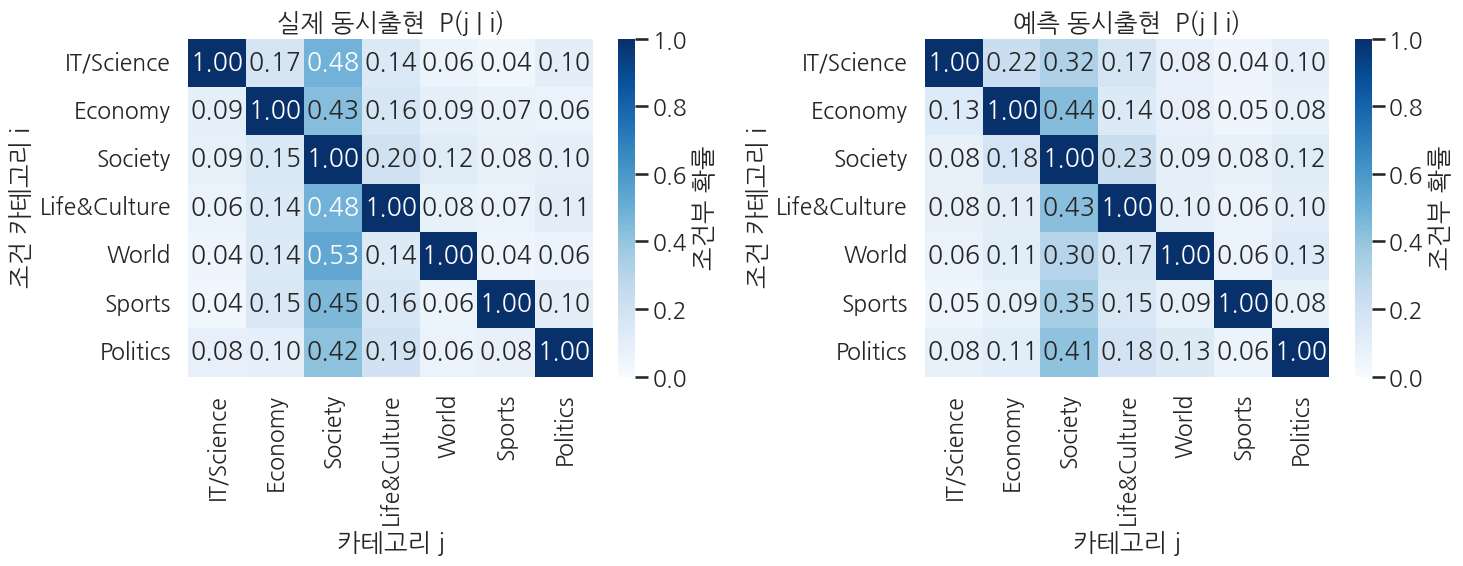

In [17]:
def cooccurrence_matrix(Y):
    # Y: (N, K) multi-hot. Returns (K, K) where M[i, j] = P(label_j=1 | label_i=1).
    Y = Y.astype(float)
    K_ = Y.shape[1]
    M = np.zeros((K_, K_))
    for i in range(K_):
        row_i = Y[:, i]
        n_i = row_i.sum()
        if n_i == 0:
            continue
        for j in range(K_):
            M[i, j] = (row_i * Y[:, j]).sum() / n_i
    return M

cooc_true = cooccurrence_matrix(labels)
cooc_pred = cooccurrence_matrix(preds)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, M, title in [
    (axes[0], cooc_true, "실제 동시출현  P(j | i)"),
    (axes[1], cooc_pred, "예측 동시출현  P(j | i)"),
]:
    sns.heatmap(
        M, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
        xticklabels=LABEL_NAMES_EN, yticklabels=LABEL_NAMES_EN,
        cbar_kws={"label": "조건부 확률"}, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("카테고리 j")
    ax.set_ylabel("조건 카테고리 i")
plt.tight_layout()
plt.show()

**해석**

- **대각선 = 1.0** — 자기 자신과는 항상 같이 등장 (정의상).
- **off-diagonal cell M[i, j]** = "카테고리 i 가 활성된 샘플 중 카테고리 j 도 활성된 비율".
- **무작위 결합의 구조** — off-diagonal 은 *균등이 아니라* 상대 카테고리 j 의 **활성률에 비례**합니다. 위 행렬에서 사회 열(0.4-0.5 대)이 다른 열(0.05-0.2)보다 뚜렷하게 높은 이유 — eval 합성의 원천인 KLUE-YNAT validation split 은 사회 비중이 높아(활성 684/1000) 어떤 카테고리와 짝지어도 상대가 사회일 확률이 큽니다. train(사회 활성 21.8%)과 분포가 다르다는 점도 함께 봐 두세요.
- **의미 상관은 없음** — 실제 사람-annotated 데이터라면 "정치+경제" 처럼 *자연스러운 의미 상관* 이 행렬에 드러나겠지만, 무작위 결합에는 그런 구조가 없습니다. 여기 보이는 쏠림은 순전히 *분포* 의 산물입니다.
- **predicted cell 이 true 보다 일관되게 높으면** → 모델이 라벨을 *너무 많이* 활성하는 경향 (over-prediction). threshold 를 0.5 보다 높게 두면 calibration 개선.

## 6. 🛠️ 변형 — 합성 샘플 직접 읽기 + threshold 옮겨보기

결합 헤드라인을 *문장 단위* 로 읽어보며 모델이 *두 주제를 모두 잡는지* 확인합니다. 평가 metric 은 전체 평균이라 *한 샘플에서 무슨 일이 일어나는지* 직관이 안 옵니다.

In [18]:
texts = list(eval_full["text"])
n_active_eval = labels.sum(axis=1)

# 활성 2개 샘플 중: 모델이 둘 다 맞춘 것 / 하나만 맞춘 것 / 자신있게 틀린 것
two_active = np.where(n_active_eval == 2)[0]
hit_both, partial, conf_wrong = -1, -1, -1
best_conf_wrong = -1.0
for idx in two_active:
    match = (preds[idx] == labels[idx]).all()
    n_correct = int((preds[idx] * labels[idx]).sum())   # 맞춘 양성 개수
    if match and hit_both < 0:
        hit_both = idx
    if (not match) and n_correct == 1 and partial < 0:
        partial = idx
    # 음성(정답 0)인데 높은 확률로 활성 = 자신있게 틀림
    wrong_pos = ((labels[idx] == 0) & (preds[idx] == 1))
    if wrong_pos.any():
        max_wrong = float(probs[idx][wrong_pos].max())
        if max_wrong > best_conf_wrong:
            best_conf_wrong, conf_wrong = max_wrong, idx

samples = [
    ("both categories correct", hit_both),
    ("partially correct (1 of 2)", partial),
    ("confidently wrong activation", conf_wrong),
]

for label_kind, idx in samples:
    if idx < 0:
        continue
    print("=" * 80)
    print(f"sample #{idx}  ({label_kind})")
    print("=" * 80)
    print(f"text: {texts[idx]}")
    print()
    print(f"{'category':>10}  {'true':>5}  {'prob':>8}  {'pred(>=0.5)':>12}  match")
    for k in range(K):
        t = int(labels[idx, k])
        p = float(probs[idx, k])
        pr = int(preds[idx, k])
        ok = "O" if t == pr else "X"
        print(f"  {LABEL_NAMES_EN[k]:>9}  {t:>5}  {p:>8.4f}  {pr:>12}    {ok}")
    true_active = [LABEL_NAMES_EN[k] for k in range(K) if labels[idx, k]]
    pred_active = [LABEL_NAMES_EN[k] for k in range(K) if preds[idx, k]]
    print()
    print(f"  true:      {true_active}")
    print(f"  predicted: {pred_active}")
    print()

sample #0  (both categories correct)
text: 새 현대미술 양식 꽃피운 故강국진 개인전 [SEP] 음성군 충북 혁신도시 본성고 2023년 개교 위해 올인

  category   true      prob   pred(>=0.5)  match
  IT/Science      0    0.0784             0    O
    Economy      0    0.0520             0    O
    Society      1    0.5631             1    O
  Life&Culture      1    0.9689             1    O
      World      0    0.0652             0    O
     Sports      0    0.0763             0    O
   Politics      0    0.0424             0    O

  true:      ['Society', 'Life&Culture']
  predicted: ['Society', 'Life&Culture']

sample #5  (partially correct (1 of 2))
text: 모스크바국제도서전에 한국관 설치…내년에는 주빈국 [SEP] 김천시 내년 예산안 1조1천200억원…올해보다 8.1% 증액

  category   true      prob   pred(>=0.5)  match
  IT/Science      0    0.0170             0    O
    Economy      1    0.2529             0    X
    Society      0    0.6295             1    X
  Life&Culture      0    0.3975             0    O
      World      1    0.6434             1    O
     Sports     

**읽는 법**

- **`true` 컬럼** — 합성 시 결합한 두 헤드라인의 카테고리. 보통 두 위치가 1.
- **`prob` 컬럼** — 각 카테고리 sigmoid 확률 (독립). 합이 1 일 필요 없음 — multi-label 의 본질.
- **`both categories correct`** — 모델이 결합 헤드라인 안의 *두 신호를 모두* 분리해 잡은 이상적 케이스.
- **`partially correct`** — 한 주제만 잡고 다른 하나는 놓침. 두 헤드라인 중 *한쪽 신호가 약했거나* 두 카테고리가 서로 헷갈리는 경우.
- **`confidently wrong`** — 정답이 0 인데 높은 확률로 활성. 결합된 두 헤드라인의 단어가 *제3의 카테고리* 신호와 겹친 경우 (예: 경제+세계 헤드라인이 '정치' 신호처럼 보임).

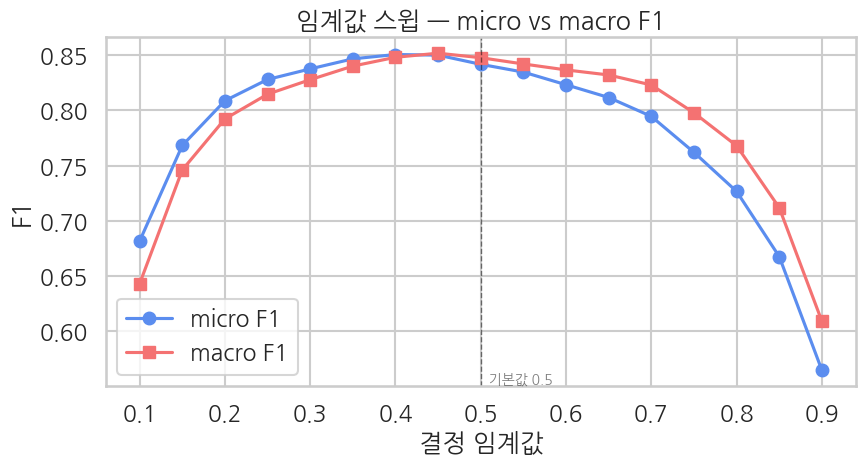

best micro F1 threshold: 0.40  (F1=0.8505)
best macro F1 threshold: 0.45  (F1=0.8517)
F1 at default 0.5:        micro=0.8416, macro=0.8476


In [19]:
# threshold 를 옮기면 micro/macro F1 이 어떻게 변하나
sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})

thresholds = np.arange(0.1, 0.91, 0.05)
micro_f1s, macro_f1s = [], []
for th in thresholds:
    preds_th = (probs >= th).astype(int)
    _, _, f1_mi, _ = precision_recall_fscore_support(labels, preds_th, average="micro", zero_division=0)
    _, _, f1_ma, _ = precision_recall_fscore_support(labels, preds_th, average="macro", zero_division=0)
    micro_f1s.append(f1_mi)
    macro_f1s.append(f1_ma)

best_micro_th = float(thresholds[int(np.argmax(micro_f1s))])
best_macro_th = float(thresholds[int(np.argmax(macro_f1s))])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, micro_f1s, "o-", label="micro F1", color="#5B8DEF")
ax.plot(thresholds, macro_f1s, "s-", label="macro F1", color="#F47272")
ax.axvline(0.5, color="black", lw=1.0, ls="--", alpha=0.5)
ax.text(0.5, ax.get_ylim()[0], "  기본값 0.5", va="bottom", fontsize=10, alpha=0.6)
ax.set_xlabel("결정 임계값")
ax.set_ylabel("F1")
ax.set_title("임계값 스윕 — micro vs macro F1")
ax.legend()
plt.tight_layout()
plt.show()

print(f"best micro F1 threshold: {best_micro_th:.2f}  (F1={max(micro_f1s):.4f})")
print(f"best macro F1 threshold: {best_macro_th:.2f}  (F1={max(macro_f1s):.4f})")
print(f"F1 at default 0.5:        micro={micro_f1s[list(np.round(thresholds,2)).index(0.5)]:.4f}, "
      f"macro={macro_f1s[list(np.round(thresholds,2)).index(0.5)]:.4f}")

**해석** — threshold 0.5 가 *항상* 최적은 아닙니다. 활성률이 낮은 카테고리가 있으면 *낮은 threshold* 가 recall 을 끌어올려 F1 이 더 좋아질 수 있습니다. 운영 단계에선 validation set 에서 *카테고리별로* 최적 threshold 를 찾아 저장해 두고 추론 시 적용 (FAQ Q1).

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `AutoModelForSequenceClassification(num_labels=7, problem_type="multi_label_classification")` | Ch 16 셋업에서 problem_type 만 변경 → BCE per-label 자동 매핑 | Ch 18 에서 메인 헤드로 그대로 |
| `datasets.Dataset.from_dict(...)` | 합성한 텍스트·라벨로 새 데이터셋 생성 | 합성 데이터 챕터에서 재등장 |
| `numpy.random.default_rng(seed)` | 재현 가능한 난수 생성기 (결합 짝짓기) | 합성 챕터마다 |
| `sklearn.metrics.hamming_loss` | 전체 (sample × label) 위치 중 틀린 비율 | multi-label 챕터마다 |
| `precision_recall_fscore_support(..., average="micro"/"macro")` | multi-label F1 — micro 는 라벨 합산, macro 는 라벨 평균 | Ch 18 |
| `roc_auc_score(..., average="macro")` | 카테고리별 AUC 의 macro 평균 | Ch 18 |
| `seaborn.FacetGrid + map_dataframe` | 7개 카테고리에 같은 KDE 를 facet 으로 | 라벨이 많은 시각화에 재등장 |

## 🎯 체크포인트 질문

1. Ch 16 과 Ch 17 의 모델이 *둘 다* `Linear(H, 7)` 헤드인데, 같은 7개 출력을 두 챕터가 *어떻게 다르게 해석* 하나요?
2. multi-label 문제를 *softmax + CrossEntropyLoss* 로 풀려고 하면 무엇이 잘못되나요? 합성 샘플 (경제+스포츠) 을 예로 한 줄 설명할 수 있나요?
3. 두 헤드라인을 `[SEP]` 로 잇는 합성 방식에서, 모델이 *두 주제를 모두 잡지 못하고 하나만 잡는* 경우는 왜 생기나요?
4. 카테고리 간 공동 활성 행렬에서 *무작위 결합* 합성인데도 true co-occurrence 의 *사회 열* 이 유난히 높습니다. 왜일까요? 실제 사람-annotated multi-label 데이터라면 이 행렬이 어떻게 달라질까요?

## ❓ FAQ

### Q1. (실무) Multi-label 에서 threshold 0.5 는 항상 옳은가요?

아닙니다. 0.5 는 *기본값* 일 뿐 카테고리마다 최적 threshold 가 다를 수 있습니다 (§6 의 threshold sweep 에서 확인했듯).

- **활성률 차이**: 활성률이 낮은 카테고리에선 0.5 가 너무 보수적 — threshold 를 0.3-0.4 로 낮추면 recall 이 크게 올라갑니다.
- **F1 최적 threshold 탐색**: validation set 에서 *카테고리별로* grid search → F1 최대 지점 선택.

```python
def best_threshold(probs_k, labels_k):
    best_f1, best_th = 0.0, 0.5
    for th in np.arange(0.1, 0.91, 0.05):
        preds_k = (probs_k >= th).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(labels_k, preds_k, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1, best_th = f1, th
    return best_th, best_f1

thresholds = [best_threshold(probs[:, k], labels[:, k])[0] for k in range(K)]
```

운영 환경에선 *카테고리별 threshold* 를 저장해 두고 추론 시 적용합니다.

### Q2. (이론) 두 헤드라인을 결합하는 합성 방식의 한계는 무엇인가요?

합성이 *무작위 결합* 이라 두 가지 한계가 있습니다.

1. **자연스러운 카테고리 상관이 사라짐** — 실제 뉴스에선 "정치+경제" 가 "스포츠+정치" 보다 훨씬 자주 같이 등장하지만, 무작위 결합의 동시출현은 *의미와 무관하게* 상대 카테고리의 활성률만 따라갑니다. 그래서 §5-2 의 true co-occurrence 에는 의미 상관 구조가 없고, 원천 split 의 분포 쏠림(사회 열)만 남습니다.
2. **두 주제가 한 문장에 *섞이지* 않고 그냥 *이어붙음*** — 진짜 multi-topic 헤드라인 (예: "삼성전자 스포츠단 창단 발표" — 경제+스포츠가 *한 문장에서 융합*) 과 달리, 결합 샘플은 `[SEP]` 로 나뉜 *두 독립 문장*. 모델이 학습하기엔 오히려 *쉬운* 편 (각 절반이 명확한 단일 카테고리 신호).

더 현실적인 합성은 *문장 수준 paraphrase* 나 *LLM 으로 multi-topic 헤드라인 생성* 이지만, 그건 입문 범위를 넘어섭니다. 핵심 — *합성 데이터의 통계적 특성은 합성 방식이 결정* 한다는 감각.

### Q3. (실무) `pos_weight` 로 카테고리 불균형을 다루려면?

`BCEWithLogitsLoss(pos_weight=...)` 가 라벨별 양성 가중치를 받습니다. 무작위 결합이라 카테고리 활성률이 KLUE-YNAT 원본 분포를 따라가 *약간 불균형* (스포츠/세계가 정치/IT 보다 많음).

```python
import torch
from torch import nn

# 라벨별 양성 비율 → pos_weight = (negative count / positive count)
pos_count = Y_train.sum(axis=0)
neg_count = len(Y_train) - pos_count
pos_weight = torch.tensor(neg_count / np.maximum(pos_count, 1), dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(outputs.logits.device))
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss
```

활성률이 낮은 카테고리는 pos_weight 가 커져 양성 샘플의 손실이 더 가중됩니다 → 모델이 그 카테고리를 더 자주 활성하도록.

### Q4. (이론) 모델이 카테고리 *간* 상관을 학습하는 메커니즘은? (loss 엔 결합 항이 없는데)

핵심은 **공유 BERT 본체** 입니다. 7개 카테고리의 logit 이 같은 768-dim CLS hidden state $h$ 에서 *별도의 7개 가중치 행* 을 통해 나옵니다.

$$z_k = w_k^\top h + b_k, \quad k = 1, \ldots, K$$

학습 중 한 합성 샘플에서 경제+스포츠가 동시 활성됐다면 $w_{\text{경제}}$ 와 $w_{\text{스포츠}}$ 가 각자 $h$ 의 관련 차원을 강조하도록 학습됩니다. Loss 에 결합 항은 없지만 *gradient 가 BERT 본체를 거쳐 흐를 때* 결합이 간접적으로 학습됩니다. 다만 Q2 에서 봤듯 무작위 결합이라 *학습할 만한 상관 구조 자체가 약합니다*.

### Q5. (실무) 헤드라인 두 개 대신 *세 개* 를 결합하면 어떻게 되나요?

활성 라벨 개수가 평균 약 2.7개 (충돌 고려) 로 늘어 *더 어려운* multi-label 이 됩니다. 코드 변경은 작습니다 — `make_multilabel` 에서 3개 인덱스를 뽑아 3개 위치를 1 로:

```python
idx = rng.integers(0, n_src, size=3 * n_samples).tolist()
# ... 3개 짝 ca, cb, cc 의 위치를 multi-hot 에서 1 로
```

단 텍스트가 더 길어져 (`max_length` 압박) 모델이 세 신호를 분리하기 더 어렵고, F1 이 떨어집니다. 이게 *Ch 18 의 보조 task* (활성 라벨 *개수* 회귀) 가 의미 있는 이유 — "몇 개 카테고리가 활성됐는가" 를 보조로 학습하면 메인 분류가 도움을 받습니다.

### Q6. (이론) micro F1 과 macro F1 중 multi-label 에선 어느 쪽을 봐야 하나요?

둘 다 봐야 하지만 보는 *이유* 가 다릅니다.

- **micro F1** — 모든 (샘플 × 카테고리) 위치를 동등하게 세서 합산. *활성률 높은 카테고리* 의 영향이 큼. "전체적으로 라벨을 얼마나 잘 맞히나" 의 종합 점수.
- **macro F1** — 카테고리 7개의 F1 을 *단순 평균*. 활성률이 낮은 카테고리도 *동등한 가중치*. "소수 카테고리도 챙기나" 의 공정성 점수.

micro 가 높은데 macro 가 *훨씬* 낮으면 → 모델이 *다수 카테고리만 잘 맞히고 소수 카테고리를 버리는* 상태. 이때 Q3 의 `pos_weight` 나 Q1 의 카테고리별 threshold 로 처치.

### Q7. (실무) 합성 multi-label 로 학습한 모델을 실제 multi-topic 뉴스에 써도 되나요?

부분적으로 됩니다. 합성 데이터로도 모델은 *각 카테고리의 단어·표현 신호* 를 학습하므로, 진짜 multi-topic 헤드라인에서도 *기본적인 카테고리 인식* 은 작동합니다. 단 Q2 에서 짚은 한계 때문에:

- *자연스러운 카테고리 상관* 을 못 배웠으니 "정치+경제 가 흔하다" 같은 사전 지식이 없음.
- *한 문장에 융합된* multi-topic (이어붙임이 아닌) 에는 약함.

실무에선 *소량의 사람-annotated multi-label 데이터* 로 fine-tune 을 한 번 더 하면 (합성 → 진짜 데이터 2단계) 격차가 크게 줄어듭니다. 합성 데이터의 가치는 *없는 라벨을 0 에서 만드는 것* 이 아니라 *모델을 task 형태에 적응시키는 워밍업* 에 있습니다.

## 🚀 삽질 코너 (선택)

다음 코드를 돌려보면 어떤 에러가 날까요?

```python
# multi-label 모델에 int 스칼라 라벨 (Ch 16 형식) 을 넣어보기
def tokenize_wrong(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    # multi-hot 벡터 대신 첫 번째 활성 카테고리의 인덱스만 (single-label 형식)
    out["labels"] = [
        next((i for i, v in enumerate(mh) if v > 0), 0)
        for mh in batch["multi_hot"]
    ]
    return out
```

힌트: `BCEWithLogitsLoss` 는 *logits 와 같은 shape 의 float 텐서* 를 라벨로 받는데, 위 코드는 *(B,) int* 를 넘깁니다. shape mismatch + dtype mismatch 두 가지 에러가 동시에 날 수 있어 메시지가 길어집니다 (Ch 13 의 삽질과 같은 함정 — 라벨 *형식* 이 problem_type 과 일치해야 함).

## 다음 챕터 예고

**Chapter 18. 한국어 BERT Auxiliary Loss — multi-label 분류 + 활성 라벨 개수 보조 회귀**

- 메인 task: Ch 17 의 multi-label 카테고리 분류 (`num_labels=7` + BCE per-label) — *완전히 동일*
- 추가: *보조 헤드* `Linear(H, 1)` 로 *활성 라벨 개수* 를 회귀 (결합한 헤드라인이 몇 개 카테고리에 걸치는가 — 1 또는 2 를 그대로 회귀)
- 손실: `L = BCE_per_label(메인) + λ · MSE(보조)` 가중합 (λ 는 hyperparameter)
- `Trainer.compute_loss` 오버라이드로 두 헤드를 동시 학습
- Ch 14 (영어 auxiliary) 의 한국어 버전 — 보조 task 만 별점 회귀 → 라벨 개수 회귀로 달라짐

> **변하는 축**: 메인 task 와 모델 본체는 그대로, *Loss 에 보조 항이 추가* 됩니다 — Loss 축의 마지막 단계 ("BCE per-label → +Auxiliary").